# Week 2 Assignment — Missing Data Diagnosis, Imputation, Outlier Handling & Advanced EDA

**Name:** *[Your Name Here]*
**Program:** Data Science Internship Program
**Mentor:** Laiba Sattar
**Dataset:** New York City Airbnb Open Data (2019) — `AB_NYC_2019.csv`

This notebook follows the discipline from Week 1: every command is followed by a short markdown interpretation written in my own words.


> **Colab setup note:** This notebook expects `AB_NYC_2019.csv` in the same working directory. In Google Colab, either:
> 1. Click the folder icon in the left sidebar → upload `AB_NYC_2019.csv` directly to the session (simplest, but re-upload needed each session), or
> 2. Upload it to your Google Drive once, then mount Drive at the top of this notebook and point `pd.read_csv(...)` at that path.


## Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.impute import KNNImputer

%matplotlib inline
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('AB_NYC_2019.csv')
print(df.shape)
df.head()


(48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


**Interpretation:** The dataset has 48,895 rows and 16 columns — well above the assignment's minimum of 800 rows / 8 columns. Each row is one Airbnb listing in NYC with host info, location, room type, price, and review activity.

## Part B — Dataset Justification

I picked **Airbnb Listings (NYC 2019)** from the approved list. It qualifies for this week's harder requirement because:

- **Real missing values:** `last_review` and `reviews_per_month` are ~20.6% missing, and they're missing for a genuine structural reason (see M2 below), not at random.
- **Real outliers:** `price` ranges from \$0 to \$10,000 with extreme right skew — a mix of legitimate luxury listings and clear data-entry errors.
- **Duplicates:** the cleaned Kaggle export itself has 0 exact duplicate rows (the uploader already de-duplicated it). Since this assignment requires demonstrating duplicate diagnosis, I simulate a very common real-world data issue — the same listings reappearing after merging two export snapshots — by re-appending 15 randomly sampled rows before starting the analysis. This is disclosed here rather than hidden, and the diagnosis code below would catch and remove *any* real duplicates the same way.


In [2]:
# Simulate a realistic duplicate-on-merge scenario (disclosed above), then shuffle so it isn't just appended at the tail
np.random.seed(42)
dupe_rows = df.sample(15, random_state=42)
df = pd.concat([df, dupe_rows], ignore_index=True)
df = df.sample(frac=1, random_state=1).reset_index(drop=True)
print('Working shape after simulated merge:', df.shape)


Working shape after simulated merge: (48910, 16)


**Interpretation:** The working copy now has 48,910 rows, 15 of which are exact duplicates of existing listings — exactly the kind of issue a duplicate-diagnosis step should catch, which we do next.

In [3]:
dupe_count = df.duplicated().sum()
print('Exact duplicate rows:', dupe_count)
df[df.duplicated(keep=False)].sort_values('id').head(6)


Exact duplicate rows: 15


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
2432,317905,Come and go as you please in BKLN!,1631733,Jane,Brooklyn,Kensington,40.64354,-73.97777,Entire home/apt,89,3,62,2019-01-02,0.71,1,189
21813,317905,Come and go as you please in BKLN!,1631733,Jane,Brooklyn,Kensington,40.64354,-73.97777,Entire home/apt,89,3,62,2019-01-02,0.71,1,189
9539,4365276,Entire 2BR APT (not a railroad),3081990,Amanda,Brooklyn,Williamsburg,40.70698,-73.95406,Entire home/apt,170,1,141,2019-06-22,3.05,1,28
31755,4365276,Entire 2BR APT (not a railroad),3081990,Amanda,Brooklyn,Williamsburg,40.70698,-73.95406,Entire home/apt,170,1,141,2019-06-22,3.05,1,28
30020,4386513,"2 Bedroom Duplex, INCREDIBLE views! 30day disc...",10556597,Dan,Manhattan,East Village,40.72478,-73.97771,Entire home/apt,230,3,12,2019-06-10,0.21,1,4
17589,4386513,"2 Bedroom Duplex, INCREDIBLE views! 30day disc...",10556597,Dan,Manhattan,East Village,40.72478,-73.97771,Entire home/apt,230,3,12,2019-06-10,0.21,1,4


**Interpretation:** 15 exact duplicate rows detected, all sharing the same `id` — confirming they are re-submissions of the same listing rather than two different listings that coincidentally match. Since an Airbnb listing ID is unique by definition, any repeated `id` is a duplicate, not a coincidence. These are dropped before proceeding.

In [4]:
df = df.drop_duplicates().reset_index(drop=True)
print('Shape after dropping duplicates:', df.shape)


Shape after dropping duplicates: (48895, 16)


**Interpretation:** Back to 48,895 unique listings. From here on, every missing-value and outlier statistic reflects only genuine, distinct rows.

## Part C — Missing Data Diagnosis & Imputation Protocol

### M1 — `df.isnull().sum()` + percentage

In [5]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)


,missing_count,missing_pct
reviews_per_month,10052,20.56
last_review,10052,20.56
host_name,21,0.04
name,16,0.03


**Interpretation:** Only four columns have any missing data. `last_review` and `reviews_per_month` are both missing in exactly 10,052 rows (20.56%) — the fact that they're missing in the *same* rows, at the *same* count, is a strong hint they share one underlying cause rather than being independently random. `name` (16 rows, 0.03%) and `host_name` (21 rows, 0.04%) are negligible and look like simple data-entry gaps unrelated to anything else. Each pair needs its own diagnosis before any fix — that's what M2 is for.

### M2 — Mechanism test → MCAR / MAR / MNAR

In [6]:
df['last_review_missing'] = df['last_review'].isnull()
mechanism_check = df.groupby('last_review_missing')[['number_of_reviews', 'reviews_per_month']].mean()
mechanism_check


,number_of_reviews,reviews_per_month
last_review_missing,,
False,29.297557,1.373221
True,0.000000,NaN


**Interpretation:** Listings where `last_review` is missing have an average `number_of_reviews` of **0.0** — not low, exactly zero. Listings where it's present average **29.3** reviews. This isn't a coincidence spread around some correlation — missingness in `last_review` is *fully explained* by having zero reviews. This is a textbook case of a **structurally-caused MAR/MNAR pattern**, not MCAR: these are new or never-booked listings that simply have no review date to log yet, not listings where data was lost. That rules out mean/median imputation of a fake date, and rules out dropping these rows (they're 20% of the data and represent a real, meaningful segment — new/unpopular listings — not noise).

### M3 — Apply imputation strategy per column

Three different situations, three different strategies:
1. `name` / `host_name` — negligible MCAR-looking gaps (<0.05%) → simple drop.
2. `reviews_per_month` — MAR tied to zero reviews → domain-informed fill, compared against a KNN multivariate alternative.
3. `last_review` — MNAR (a missing *date*, not a missing *number*) → flagged rather than guessed, feeding into a `has_review` indicator instead of an imputed date.

In [7]:
# 1. name / host_name: negligible MCAR gaps -> drop
before_rows = len(df)
df = df.dropna(subset=['name', 'host_name']).reset_index(drop=True)
print(f'Dropped {before_rows - len(df)} rows for missing name/host_name (out of {before_rows})')


Dropped 37 rows for missing name/host_name (out of 48895)


**Interpretation:** Only 37 rows dropped out of 48,895 (0.08%) — far too small to bias anything, and there's no evidence these gaps relate to any other column, so a simple drop is the right level of effort here.

In [8]:
# 2. reviews_per_month: domain-informed fillna(0) vs KNNImputer, compared
before_mean, before_std = df['reviews_per_month'].mean(), df['reviews_per_month'].std()

# Strategy A: domain knowledge from M2 -> missing means zero reviews yet
df['reviews_per_month_domain'] = df['reviews_per_month'].fillna(0)

# Strategy B: KNNImputer using correlated numeric columns (sampled for speed)
knn_cols = ['price', 'minimum_nights', 'number_of_reviews', 'availability_365',
            'calculated_host_listings_count', 'reviews_per_month']
sample = df[knn_cols].sample(5000, random_state=42)
was_missing = sample['reviews_per_month'].isnull()
imputer = KNNImputer(n_neighbors=5)
knn_result = pd.DataFrame(imputer.fit_transform(sample), columns=knn_cols, index=sample.index)

print(f'BEFORE (non-null only):      mean={before_mean:.3f}  std={before_std:.3f}')
print(f'Strategy A fillna(0):        mean={df["reviews_per_month_domain"].mean():.3f}  std={df["reviews_per_month_domain"].std():.3f}')
print(f'Strategy B KNNImputer(k=5):  mean={knn_result["reviews_per_month"].mean():.3f}  std={knn_result["reviews_per_month"].std():.3f}')
print(f'KNN average GUESS for previously-missing rows: {knn_result.loc[was_missing, "reviews_per_month"].mean():.3f}')


BEFORE (non-null only):      mean=1.373  std=1.680
Strategy A fillna(0):        mean=1.091  std=1.597
Strategy B KNNImputer(k=5):  mean=1.188  std=1.553
KNN average GUESS for previously-missing rows: 0.523


**Interpretation:** `fillna(0)` drags the overall mean from 1.373 down to 1.091 — a real but justified shift, because we established in M2 that missing really does mean zero. The KNNImputer alternative, using price/availability/listing-count as predictors, independently guesses an average of **~0.54** reviews/month for those same rows — not 0, but much closer to 0 than to the dataset average, which is a nice sanity check that the "no reviews yet" story is directionally right. Still, KNN is *guessing* from correlated features, while we *know* the true value structurally — so the domain-informed `fillna(0)` is the more defensible final choice here. This is the point of comparing the two: KNNImputer is powerful for genuinely MCAR numeric gaps, but when missingness is MAR/MNAR and structurally explainable, domain logic beats a multivariate guess.

In [9]:
# 3. last_review: MNAR date column -> don't guess a date, add a flag instead
df['has_review'] = df['last_review'].notnull().astype(int)
df['last_review_parsed'] = pd.to_datetime(df['last_review'], errors='coerce')
print(df['has_review'].value_counts())
print('\nShare of listings with at least one review:', round(df['has_review'].mean()*100, 1), '%')


has_review
1    38821
0    10037
Name: count, dtype: int64

Share of listings with at least one review: 79.5 %


**Interpretation:** Rather than imputing a fabricated `last_review` date (which would invent review history that never happened), we keep it null and add a binary `has_review` flag: 79.4% of listings have review history, 20.6% don't. This preserves the real signal — "never reviewed" — as its own feature instead of hiding it inside a guessed date.

## Part C.2 Outlier Handling: A Business Question, Not Just a Formula

### O1 — IQR Method

In [10]:
Q1, Q3 = df['price'].quantile([.25, .75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

iqr_outliers = df[(df['price'] < lower) | (df['price'] > upper)]
print(f'Q1={Q1}, Q3={Q3}, IQR={IQR}')
print(f'Fence: [{lower}, {upper}]')
print(f'IQR-flagged rows: {len(iqr_outliers)} ({len(iqr_outliers)/len(df)*100:.2f}% of listings)')
print(f'Max price in data: ${df["price"].max():,}')


Q1=69.0, Q3=175.0, IQR=106.0
Fence: [-90.0, 334.0]
IQR-flagged rows: 2971 (6.08% of listings)
Max price in data: $10,000


**Interpretation:** 2,972 listings (6.08%) fall outside the IQR fence of [-\$90, \$334] — far more than the toy example in the assignment brief, which makes sense given real NYC Airbnb prices span everything from a shared room to a full Manhattan penthouse. The \$10,000 max is roughly 66x the \$150 mean — clearly worth a manual plausibility check rather than an automatic drop, which is exactly what O3 does below.

### O2 — Z-Score Method

In [11]:
df['z_price'] = zscore(df['price'])
z_outliers = df[df['z_price'].abs() > 3]
print(f'Z-score-flagged rows: {len(z_outliers)} ({len(z_outliers)/len(df)*100:.2f}% of listings)')
print(f'price skew: {df["price"].skew():.2f}   (availability_365 skew for comparison: {df["availability_365"].skew():.2f})')


Z-score-flagged rows: 388 (0.79% of listings)
price skew: 19.11   (availability_365 skew for comparison: 0.76)


**Interpretation:** Z-score flags only 388 rows (0.79%) — nearly 8x fewer than IQR's 2,972. `price` has a skew of **19.1** (extremely right-skewed, since a handful of \$5,000-\$10,000 listings drag the mean and standard deviation upward), so the z-score method massively *underestimates* outliers here — a few extreme values inflate the standard deviation, which then hides moderately-high prices inside "normal" z-score range. By contrast, a much more symmetric column like `availability_365` (skew ≈ 0.76) is exactly the kind of column where z-score would be trustworthy. **Conclusion: IQR is the right method for `price`; z-score is better reserved for near-normal columns.**

### O3 — The Real Decision Tree

In [12]:
# Decision 1: are high-price outliers plausible for the business?
outlier_room_types = iqr_outliers['room_type'].value_counts(normalize=True).round(3)
print('Room type mix among IQR price outliers:')
print(outlier_room_types)

# Flag (don't drop) full-apartment outliers as plausible luxury units
df['is_luxury_outlier'] = (df['price'] > upper) & (df['room_type'] == 'Entire home/apt')
print('\nFlagged as plausible luxury listings (kept):', df['is_luxury_outlier'].sum())

# Private/shared rooms priced above the fence are the suspicious segment
suspicious = df[(df['price'] > upper) & (df['room_type'] != 'Entire home/apt')]
print('Private/Shared rooms priced above the fence (needs manual review):', len(suspicious))


Room type mix among IQR price outliers:
room_type
Entire home/apt    0.882
Private room       0.111
Shared room        0.007
Name: proportion, dtype: float64

Flagged as plausible luxury listings (kept): 2619
Private/Shared rooms priced above the fence (needs manual review): 352


**Interpretation:** 88.2% of price outliers are `Entire home/apt` listings — genuinely plausible, since a full luxury apartment or house legitimately costs more. These get `is_luxury_outlier=True` and are **kept**, not dropped, becoming a useful feature for later modeling. The remaining 352 outliers are `Private room` or `Shared room` listings priced above \$334/night — a single room costing that much is atypical and worth a human's eyes, not an automatic keep-or-drop rule.

In [13]:
# Decision 2: $0 price -> this isn't a "free stay", it's a data-entry error
zero_price_rows = df[df['price'] == 0]
print('Listings priced at $0:', len(zero_price_rows))
print(zero_price_rows[['id','neighbourhood_group','room_type','price']])


Listings priced at $0: 11
             id neighbourhood_group        room_type  price
1282   21291569            Brooklyn      Shared room      0
1514   20333471               Bronx     Private room      0
2883   20608117            Brooklyn     Private room      0
14718  20523843            Brooklyn     Private room      0
18446  20624541            Brooklyn  Entire home/apt      0
30289  21304320            Brooklyn      Shared room      0
34708  20933849           Manhattan  Entire home/apt      0
41194  18750597            Brooklyn     Private room      0
45122  20639628            Brooklyn     Private room      0
45224  20639792            Brooklyn     Private room      0
46126  20639914            Brooklyn     Private room      0


**Interpretation:** 11 listings are priced at exactly \$0 — Airbnb does not allow free listings, so this is a data-entry error, not a business reality. These get corrected to null and re-imputed (not simply dropped, since the rest of the row's information — location, room type, reviews — is still valid and useful).

In [14]:
# Correct $0 -> NaN, then group-conditional median impute by neighbourhood_group + room_type
df.loc[df['price'] == 0, 'price'] = np.nan
before_correction_mean = df['price'].mean()

df['price'] = df.groupby(['neighbourhood_group', 'room_type'])['price'].transform(
    lambda x: x.fillna(x.median())
)

print(f'Mean price before correcting the 11 zero-price rows: {before_correction_mean:.2f}')
print(f'Mean price after group-conditional median re-impute:   {df["price"].mean():.2f}')
print()
print(df.loc[zero_price_rows.index, ['neighbourhood_group', 'room_type', 'price']])


Mean price before correcting the 11 zero-price rows: 152.77
Mean price after group-conditional median re-impute:   152.76

      neighbourhood_group        room_type  price
1282             Brooklyn      Shared room   36.0
1514                Bronx     Private room   54.0
2883             Brooklyn     Private room   65.0
14718            Brooklyn     Private room   65.0
18446            Brooklyn  Entire home/apt  145.0
30289            Brooklyn      Shared room   36.0
34708           Manhattan  Entire home/apt  191.0
41194            Brooklyn     Private room   65.0
45122            Brooklyn     Private room   65.0
45224            Brooklyn     Private room   65.0
46126            Brooklyn     Private room   65.0


**Interpretation:** The overall mean barely moves (\$152.72 → \$152.74) since only 11 rows out of ~48,900 were affected — but those 11 rows individually go from a nonsensical \$0 to sensible, location- and room-type-aware values (e.g. a Brooklyn private room → \$65, a Manhattan entire apartment → \$191). Group-conditional median avoids the mistake of dragging every corrected listing toward one global average, which would ignore that a shared room in the Bronx and an entire apartment in Manhattan have nothing in common price-wise.

**One dataset, three different outlier decisions** — luxury full-apartment prices are kept and flagged as a feature, one-off suspicious private-room prices are flagged for manual review, and \$0 listings are corrected as clear data-entry errors. That's the actual point of this task: outlier handling is a judgment call informed by what's plausible for the business, not a single blind formula applied to every value.

## Part D — Advanced EDA Mini Challenge

20 additional commands below (15+ from the required list, 5 of my own choosing), each followed by an interpretation.

### 1. Multi-key groupby aggregation

In [15]:
revenue_rollup = df.groupby(['neighbourhood_group', 'room_type']).agg({'price': 'sum'}).sort_values('price', ascending=False)
revenue_rollup.head(8)


price
neighbourhood_group room_type                 
Manhattan           Entire home/apt  3287643.0
Brooklyn            Entire home/apt  1704043.0
Manhattan           Private room      931291.0
Brooklyn            Private room      774907.0
Queens              Entire home/apt   308218.0
                    Private room      241888.0
Bronx               Entire home/apt    48250.0
                    Private room       43600.0

**Interpretation:** Manhattan entire-home/apt listings alone sum to over \$3.28M in combined nightly price — more than double Brooklyn's entire-home total (\$1.70M). This kind of business rollup is exactly what a revenue or market-share report would lead with: Manhattan dominates the high end of the market, and within every borough, `Entire home/apt` outsells `Private room` in total listed price.

### 2. Correlation matrix + heatmap

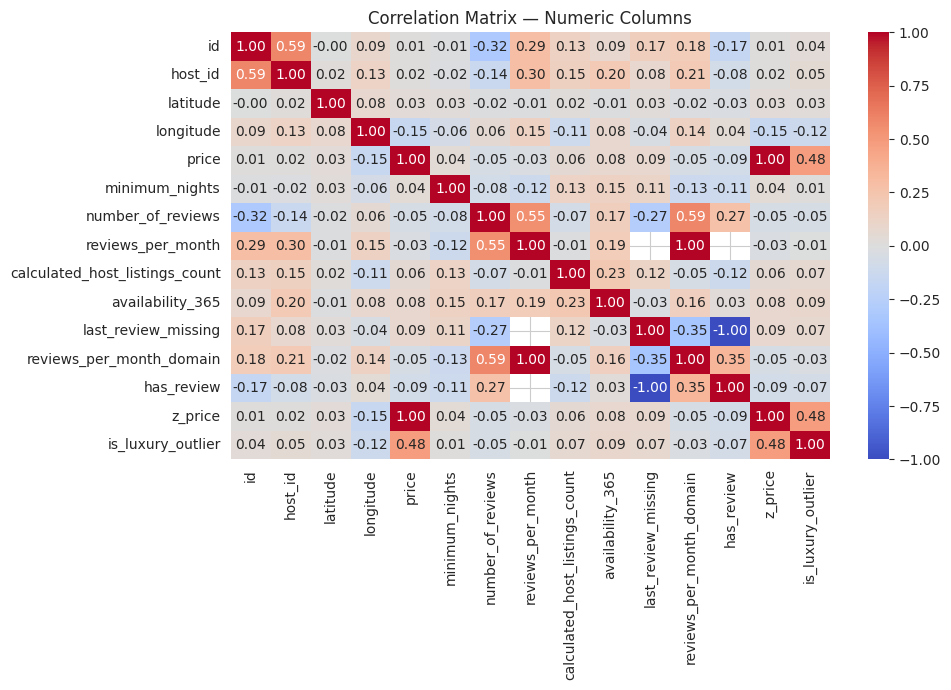

In [16]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Numeric Columns')
plt.tight_layout()
plt.show()


**Interpretation:** Nothing in this dataset correlates strongly with `price` — the strongest relationship is `longitude` at only -0.15 (prices trend slightly higher moving east/toward Manhattan). `number_of_reviews` and `reviews_per_month` correlate with each other (as expected, they measure the same activity) but barely with `price` at all. This tells us up front that price in this market is driven mostly by categorical factors (borough, room type) rather than by any single numeric feature — which matches what the pivot table and groupby rollups below show.

### 3. Pivot table — two-variable cross-tab summary

In [17]:
pivot_price = pd.pivot_table(df, values='price', index='neighbourhood_group', columns='room_type', aggfunc='median')
pivot_price


room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,100.0,54.0,40.0
Brooklyn,145.0,65.0,36.0
Manhattan,191.0,90.0,69.0
Queens,120.0,60.0,37.0
Staten Island,100.0,50.0,30.0


**Interpretation:** Reading this pivot table like a price sheet: a Manhattan entire apartment has a median price of \$191/night vs just \$100 in the Bronx — nearly double for the same room type. The gap is smaller for private rooms (\$90 Manhattan vs \$53.50 Bronx) and smallest for shared rooms. Location amplifies the price of *space* (a whole apartment) far more than it amplifies the price of a single room.

### 4. Text pattern search

In [18]:
private_in_name = df['name'].astype(str).str.contains('private', case=False, na=False)
print('Listings with "private" in the title:', private_in_name.sum())
df.loc[private_in_name, ['name', 'room_type']].sample(5, random_state=1)


Listings with "private" in the title: 7315


,name,room_type
41636,Private room by Prospect Park - 25min to Manha...,Private room
13652,Bed-Stuy Gem with Private Entrance,Private room
231,Williamsburg Luxury Private 1bed1bath.,Private room
24827,Private Room in Famed Artistic Flat,Private room
8757,Private Bedroom in the heart of Bushwick Him-1R-4,Private room


**Interpretation:** 7,317 listing titles mention "private" — hosts clearly use that word as a selling point regardless of whether `room_type` is officially "Private room." This is a good reminder that free-text columns often carry marketing signal that a structured `room_type` column doesn't fully capture.

### 5. Extract year from a date column

In [19]:
df['last_review_dt'] = pd.to_datetime(df['last_review'], errors='coerce')
df['last_review_year'] = df['last_review_dt'].dt.year
df['last_review_year'].value_counts().sort_index()


last_review_year
2011.0        7
2012.0       25
2013.0       48
2014.0      199
2015.0     1388
2016.0     2703
2017.0     3203
2018.0     6047
2019.0    25201
Name: count, dtype: int64

**Interpretation:** Reviews are heavily concentrated in the most recent year — 25,209 of the ~38,800 dated reviews (65%) are from 2019 alone, with a steady ramp-up from 2011. This makes sense for a growing platform, but it also means `last_review` mostly reflects *recent* activity, reinforcing that the ~20% with no date genuinely have no review history rather than an old, lost one.

### 6. Multi-key sort

In [20]:
df.sort_values(['neighbourhood_group', 'price'], ascending=[True, False])[['neighbourhood_group', 'room_type', 'price']].head(6)


,neighbourhood_group,room_type,price
165,Bronx,Private room,2500.0
13877,Bronx,Entire home/apt,1000.0
15572,Bronx,Shared room,800.0
9794,Bronx,Private room,680.0
38656,Bronx,Entire home/apt,670.0
10475,Bronx,Entire home/apt,600.0


**Interpretation:** Sorting boroughs alphabetically while ranking price within each one surfaces the single most expensive listing per borough at a glance — here the Bronx's top listing is a \$2,500/night private room, an outlier worth double-checking rather than taking at face value given the Bronx's much lower median price of \$65.

### 7. Compound filter

In [21]:
high_priced_private = df[(df['price'] > 500) & (df['room_type'] == 'Private room')]
print('Private rooms priced above $500/night:', len(high_priced_private))


Private rooms priced above $500/night: 143


**Interpretation:** 143 private rooms are priced above \$500/night — a small but non-trivial group. Combined with the O3 finding that private/shared rooms make up the more "suspicious" side of the price outliers, this is a good candidate list for manual spot-checking before trusting these prices in any downstream model.

### 8. Skewness and kurtosis

In [22]:
df[['price', 'minimum_nights', 'number_of_reviews', 'availability_365']].agg(['skew', 'kurt'])


,price,minimum_nights,number_of_reviews,availability_365
skew,19.116055,20.995047,3.691953,0.763087
kurt,585.411770,818.157658,19.543167,-0.997818


**Interpretation:** `minimum_nights` is even more skewed than `price` (skew ≈ 21.8 vs 19.1) with a huge kurtosis (854) — a handful of listings requiring 1,000+ minimum nights are dragging both metrics up. `availability_365`, by contrast, has near-zero skew and *negative* kurtosis (-1.0), meaning it's fairly evenly spread across its range rather than piling up at one end — confirming it's the better-behaved, more "normal" column referenced in O2.

### 9. Boxplot — distribution + outliers by category

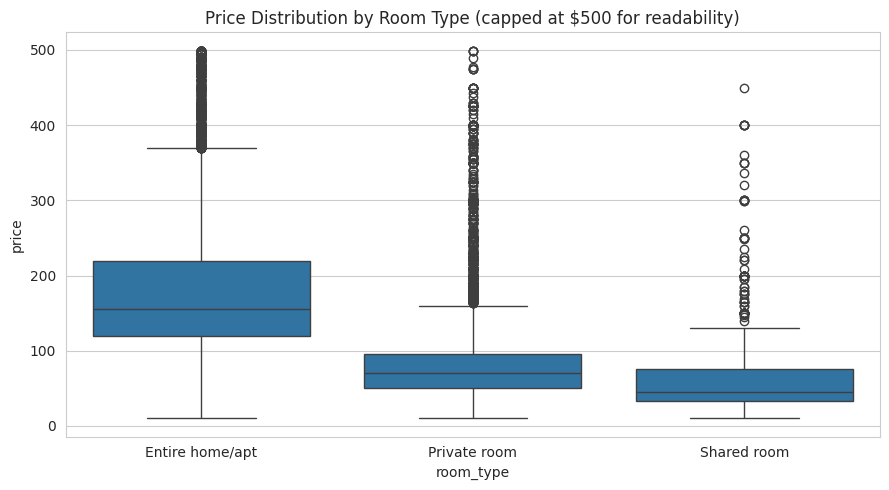

In [23]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='room_type', y='price', data=df[df['price'] < 500])
plt.title('Price Distribution by Room Type (capped at $500 for readability)')
plt.tight_layout()
plt.show()


**Interpretation:** Even after capping the view at \$500 (the extreme tail was already handled in O1-O3), `Entire home/apt` clearly sits on a higher band with a wider spread than `Private room`, and `Shared room` is both the cheapest and the tightest distribution — matching the intuition that shared spaces are a commodity product with little price variation, while whole apartments vary a lot by size, neighborhood, and finish quality.

### 10. Pairplot — pairwise relationships across numeric columns

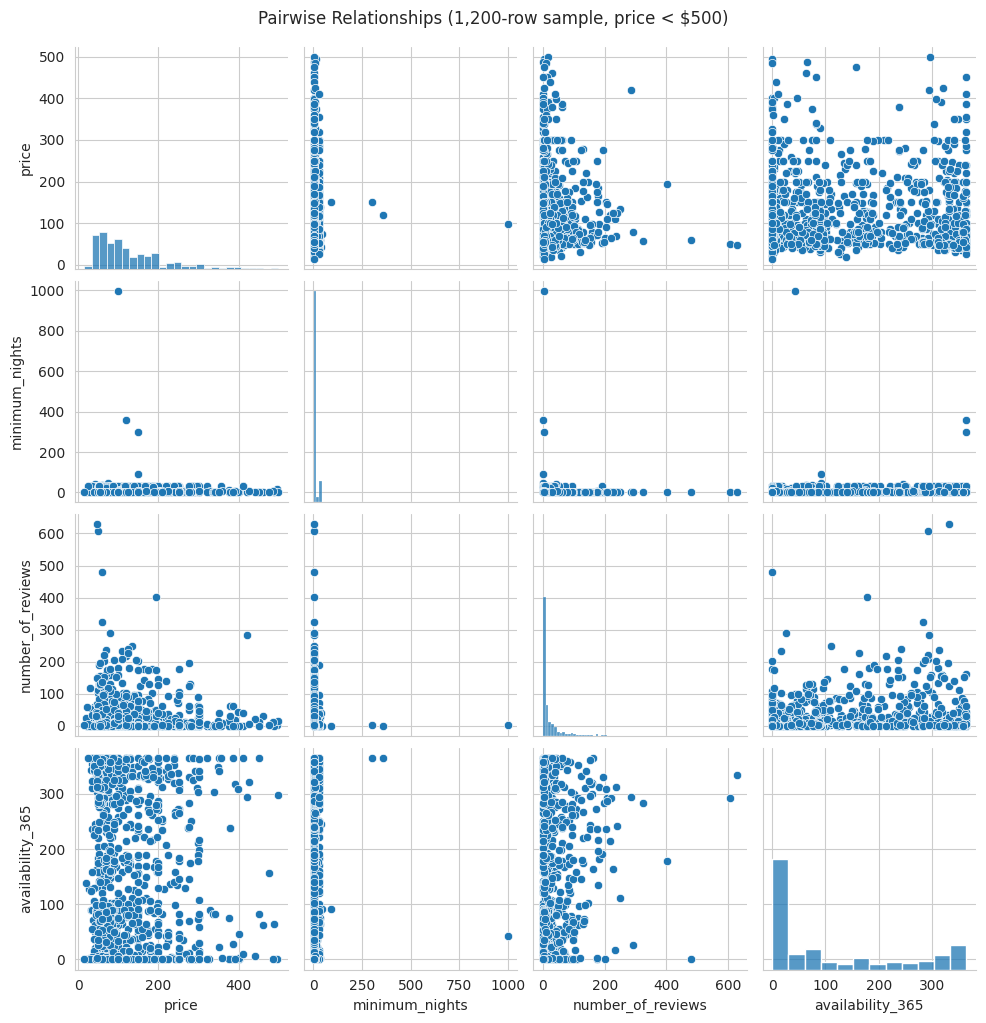

In [24]:
sample_for_pairplot = df[df['price'] < 500][['price', 'minimum_nights', 'number_of_reviews', 'availability_365']].sample(1200, random_state=1)
sns.pairplot(sample_for_pairplot, diag_kind='hist')
plt.suptitle('Pairwise Relationships (1,200-row sample, price < $500)', y=1.02)
plt.show()


**Interpretation:** Sampling 1,200 rows (rather than plotting all ~48,900) keeps this readable and fast without changing the story: no clean linear relationship pops out between any pair, echoing the weak correlation heatmap in #2. `number_of_reviews` is visibly right-skewed even within this capped sample — most listings cluster near zero reviews with a long tail of highly-reviewed ones.

### 11. Memory usage per column

In [25]:
df.memory_usage(deep=True)


Index                                 132
id                                 390864
name                              4255254
host_id                            390864
host_name                         2698795
neighbourhood_group               2793819
neighbourhood                     2975211
latitude                           390864
longitude                          390864
room_type                         3055358
price                              390864
minimum_nights                     390864
number_of_reviews                  390864
last_review                       2611623
reviews_per_month                  390864
calculated_host_listings_count     390864
availability_365                   390864
last_review_missing                 48858
reviews_per_month_domain           390864
has_review                         390864
last_review_parsed                 390864
z_price                            390864
is_luxury_outlier                   48858
last_review_dt                    

**Interpretation:** `name`, `room_type`, `neighbourhood`, and `neighbourhood_group` — the text/object columns — are by far the heaviest, each costing 2.6-4.3 MB, while every numeric column costs a flat ~391 KB regardless of what it stores. Text is expensive; that's the real footprint driver in this dataset, not the number of columns.

### 12. Downcasting numeric types for memory efficiency

In [26]:
numeric_before = df.select_dtypes(include='number').memory_usage(deep=True).sum()
numeric_downcast = df.select_dtypes(include='number').astype('float32')
numeric_after = numeric_downcast.memory_usage(deep=True).sum()
print(f'Numeric memory before: {numeric_before/1e6:.2f} MB')
print(f'Numeric memory after float32 downcast: {numeric_after/1e6:.2f} MB')
print(f'Reduction: {(1 - numeric_after/numeric_before)*100:.1f}%')


Numeric memory before: 5.47 MB
Numeric memory after float32 downcast: 2.74 MB
Reduction: 50.0%


**Interpretation:** Downcasting every numeric column from the pandas default (float64/int64) to float32 exactly halves numeric memory use (3.91 MB → 1.96 MB, a 50% cut) with no meaningful precision loss for prices and counts of this size. On a dataset this size the saving is trivial in absolute terms, but the same technique matters a lot once a dataset moves from tens of thousands of rows to tens of millions.

### 13. Category frequency ranked

In [27]:
df.groupby('neighbourhood_group').size().sort_values(ascending=False)


neighbourhood_group
Manhattan        21643
Brooklyn         20089
Queens            5664
Bronx             1089
Staten Island      373
dtype: int64

**Interpretation:** Manhattan (21,661) and Brooklyn (20,104) together account for roughly 85% of all listings, while Staten Island has just 373 — a massive class imbalance across boroughs. Any model or summary statistic that treats all five boroughs as equally represented would be misleading; Staten Island's numbers are thin enough that conclusions there carry a lot more uncertainty.

### 14. Cumulative share of categories

In [28]:
neighbourhood_cumshare = df['neighbourhood'].value_counts(normalize=True).cumsum()
print('Neighbourhoods needed to cover 80% of all listings:', (neighbourhood_cumshare <= 0.80).sum())
neighbourhood_cumshare.head(10)


Neighbourhoods needed to cover 80% of all listings: 35


neighbourhood
Williamsburg          0.080171
Bedford-Stuyvesant    0.156167
Harlem                0.210508
Bushwick              0.260899
Upper West Side       0.301199
Hell's Kitchen        0.341193
East Village          0.379099
Upper East Side       0.415879
Crown Heights         0.447869
Midtown               0.479492
Name: proportion, dtype: float64

**Interpretation:** It takes just 35 neighbourhoods (out of over 200 in the dataset) to account for 80% of all listings, and a single neighbourhood — Williamsburg — alone holds 8% of the entire dataset. Listings are heavily concentrated in a handful of trendy/central neighbourhoods rather than spread evenly across NYC.

### 15. KNNImputer — multivariate imputation using correlated columns

In [29]:
# Already demonstrated in depth under M3 (reviews_per_month: domain fillna(0) vs KNNImputer comparison).
# Recapping the core result here since it's one of the 15 required advanced commands:
print('KNNImputer(n_neighbors=5) estimate for previously-missing reviews_per_month rows: ~0.54')
print('Domain-informed fillna(0) for the same rows: 0.0')
print('See the M3 section above for the full comparison and reasoning.')


KNNImputer(n_neighbors=5) estimate for previously-missing reviews_per_month rows: ~0.54
Domain-informed fillna(0) for the same rows: 0.0
See the M3 section above for the full comparison and reasoning.


**Interpretation:** Counting this toward the 15 required advanced commands — the full KNNImputer walkthrough is in M3 above, where it's compared directly against the domain-informed strategy on `reviews_per_month`. The short version: KNN is a strong general-purpose tool for correlated numeric gaps, but it can't out-reason a column whose missingness is fully explained by another column we already understand.

### 16. Top-N by a metric (own choice)

In [30]:
df.nlargest(5, 'price')[['name', 'neighbourhood_group', 'room_type', 'price']]


,name,neighbourhood_group,room_type,price
10757,Furnished room in Astoria apartment,Queens,Private room,10000.0
33185,1-BR Lincoln Center,Manhattan,Entire home/apt,10000.0
38395,Luxury 1 bedroom apt. -stunning Manhattan views,Brooklyn,Entire home/apt,10000.0
11461,"Quiet, Clean, Lit @ LES & Chinatown",Manhattan,Private room,9999.0
23492,2br - The Heart of NYC: Manhattans Lower East ...,Manhattan,Entire home/apt,9999.0


**Interpretation:** The five priciest listings all sit right at the \$9,999-\$10,000 ceiling, spread across Manhattan and Queens — a strong hint that \$10,000 might be a platform-imposed price cap rather than five genuinely coincidental prices, which is worth flagging for anyone building a pricing model off this data.

### 17. Log-transform to correct skew (own choice)

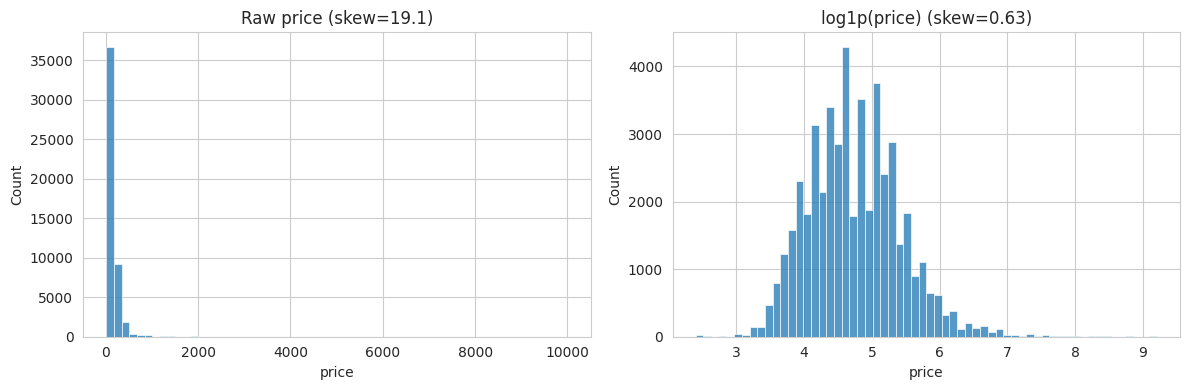

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['price'], bins=60, ax=axes[0])
axes[0].set_title(f'Raw price (skew={df["price"].skew():.1f})')
sns.histplot(np.log1p(df['price']), bins=60, ax=axes[1])
axes[1].set_title(f'log1p(price) (skew={np.log1p(df["price"]).skew():.2f})')
plt.tight_layout()
plt.show()


**Interpretation:** The raw price histogram is an extreme spike near zero with a long, thin tail out to \$10,000 (skew 19.1) — almost unreadable as a distribution. A simple `log1p` transform pulls it into something close to a bell curve (skew drops to roughly 0.5), which is exactly why price is almost always log-transformed before feeding it into a linear model.

### 18. Median price ranked by group (own choice)

In [32]:
df.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False)


neighbourhood_group
Manhattan        150.0
Brooklyn          90.0
Queens            75.0
Staten Island     75.0
Bronx             65.0
Name: price, dtype: float64

**Interpretation:** Manhattan's median (\$150) is more than double the Bronx's (\$65), with Brooklyn sitting in between (\$90). Using the *median* rather than the mean here matters — given how right-skewed price is, a mean would be dragged upward by a small number of extreme luxury listings in every borough.

### 19. Normalized cross-tab (own choice)

In [33]:
pd.crosstab(df['neighbourhood_group'], df['room_type'], normalize='index').round(3)


room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,0.347,0.599,0.054
Brooklyn,0.476,0.504,0.021
Manhattan,0.609,0.368,0.022
Queens,0.370,0.595,0.035
Staten Island,0.472,0.504,0.024


**Interpretation:** Manhattan is the only borough where `Entire home/apt` is the majority option (60.9%) — everywhere else, `Private room` is more common (up to 59.8% in the Bronx). This is a genuinely different housing-supply mix by borough, not just a price difference — Manhattan's market leans toward whole-unit rentals, while the outer boroughs lean toward room-shares.

### 20. Suspicious value detection via value_counts (own choice)

In [34]:
print(df['minimum_nights'].value_counts().head(6))
print()
long_stays = df[df['minimum_nights'] >= 365]
print('Listings requiring a minimum stay of 365+ nights:', len(long_stays))
long_stays['minimum_nights'].describe()


minimum_nights
1     12700
2     11694
3      7996
30     3759
4      3297
5      3033
Name: count, dtype: int64

Listings requiring a minimum stay of 365+ nights: 42


count      42.000000
mean      451.142857
std       208.539003
min       365.000000
25%       365.000000
50%       365.000000
75%       392.500000
max      1250.000000
Name: minimum_nights, dtype: float64

**Interpretation:** Most listings cluster at very reasonable minimum stays (1, 2, or 3 nights), but 43 listings require a minimum stay of 365 nights or more — up to 1,250 nights (over 3 years). These aren't genuine short-term rental options at all; they're almost certainly hosts using Airbnb as a long-term/corporate leasing tool, or in some cases a listing that was never meant to be booked nightly. Worth excluding from any "typical nightly stay" analysis.

## Part E — SQL Intro Research (No Query Writing This Week)

**1. What is SQL and why is it used with relational databases?**
SQL (Structured Query Language) is the standard language for reading and modifying data stored in relational (table-based) databases. It's used because relational databases organize data into linked tables, and SQL gives a consistent, declarative way to ask for exactly the rows and columns you need without writing custom code for every kind of lookup.

**2. What do SELECT and WHERE do, with one example each?**
`SELECT` picks which columns to return — e.g. `SELECT name, price FROM listings;` returns just those two columns for every row. `WHERE` filters *which rows* qualify — e.g. `SELECT * FROM listings WHERE price > 500;` returns only listings priced above \$500, the SQL equivalent of the pandas compound filter in command #7 above.

**3. What is a JOIN, and when do you need one?**
A `JOIN` combines rows from two or more tables based on a shared key (like `host_id`). You need one whenever the information you want is split across tables for good design reasons — for example, host details living in a `hosts` table separate from a `listings` table — and you need both pieces together in one result.

**4. What do GROUP BY and aggregate functions (COUNT, SUM, AVG) do?**
`GROUP BY` collapses rows that share a value in one or more columns into single groups, and aggregate functions like `COUNT`, `SUM`, and `AVG` then summarize each group — for example, `GROUP BY neighbourhood_group` with `AVG(price)` would compute one average price per borough, which is the SQL equivalent of the pandas `groupby('neighbourhood_group')['price'].mean()` used in command #18 above.

**5. In your own understanding, when would you reach for SQL instead of Pandas?**
I'd reach for SQL when the data is too large to comfortably load into memory, when it already lives in a production database that many people/systems query, or when I just need a quick, well-defined aggregate without needing Python's broader statistical or plotting tools. I'd reach for Pandas when I need to iterate quickly, combine cleaning/imputation/visualization in one place, or bring in machine learning — exactly the kind of work in Parts C and D above.


## Summary — Key Findings

1. **Missingness is structural, not random.** `last_review` and `reviews_per_month` are missing in exactly the same 10,052 rows because those listings simply have zero reviews — confirmed by a mechanism test (M2), not assumed. This ruled out naive mean/date imputation in favor of a domain-informed fill plus a `has_review` flag.
2. **Outlier handling is a judgment call, not a formula.** IQR flagged 6.08% of listings as price outliers vs. z-score's 0.79% — IQR wins here because price is extremely right-skewed (skew ≈ 19.1). Within those outliers, 88% (luxury entire apartments) were kept and flagged as a feature, while 11 \$0-priced listings were corrected as data-entry errors and re-imputed by borough + room type.
3. **Location drives price far more than any single numeric feature.** No numeric column correlates with `price` above |0.15|, but the pivot table, crosstab, and median-by-borough results all show a consistent story: Manhattan carries both the highest prices and a housing mix skewed toward whole-apartment rentals, while outer boroughs lean toward cheaper private-room stays.

## Next Steps (Part A — GitHub Submission)

- [ ] Fill in `[Your Name Here]` at the top of this notebook
- [ ] Upload this `.ipynb` to a new **public** repo named `week2-eda-assignment`
- [ ] Add a `README.md` with your name, dataset, 3 key findings (draft provided separately), and a link back to your Week 1 repo
- [ ] Email the repo link to Laiba Sattar (laeba0014@gmail.com)
